# Ground-truth circuits: multistability and oscillation

Every other tutorial fits real data, where the true regulatory network is unknown and the
velocity field is itself an estimate. This one fits circuits whose interaction matrix is written
down in advance, so inference can be scored against an exact answer and separated from every
uncertainty that real data brings.

Two circuits, chosen because they fail in opposite ways for a model that is too simple:

- a **two-gene toggle switch**, which settles into one of two stable states depending on where
  it starts, and
- a **three-gene repressilator**, which never settles at all and instead runs a limit cycle.

**What you will do**

1. Write down each circuit and confirm it is already in the scHopfield form.
2. Simulate observations from it.
3. Recover the interaction matrix under three levels of structural prior and score the result
   against the truth.
4. Watch recovery degrade as observation noise rises.
5. See why the energy landscape explains the toggle switch and why the repressilator needs the
   Jacobian read alongside it.
6. See what a linear model cannot do at all.

**Requirements.** scHopfield only. No dataset, no download, no GPU. Everything here is
simulated in the notebook.

**Runtime.** About ten minutes, almost all of it in the nine circuit fits. These run on the CPU
deliberately: the circuits are small enough that a GPU buys nothing, and a CPU fit gives the same
numbers on any machine.

In [1]:
import time

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy.optimize import brentq

import scHopfield as sch
from scHopfield.validation.circuits import ToggleCircuit, OscillatorCircuit

np.set_printoptions(precision=4, suppress=True)
DEVICE = "cpu"
print("scHopfield", sch.__version__)

scHopfield 1.0.1


.../site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The toggle switch

Two genes that inhibit each other and activate themselves:

$$\dot{x}_i = a\,\sigma(x_i) - b\,\sigma(x_j) + I_i - \gamma x_i .$$

That is already the scHopfield equation $\dot{x} = W\sigma(x) - \Gamma x + I$, with the
autoregulation on the diagonal of $W$ and the mutual inhibition off it. Nothing is approximated
in going from the circuit to the model, so any error we measure later is inference error and not
a modeling mismatch.

Note that $W$ comes out **symmetric**. That is not a coincidence of this parameter choice, it is
what mutual inhibition of equal strength means, and section 5 shows what follows from it.

In [2]:
toggle = ToggleCircuit()      # a=5, b=4, k=1, n=4, gamma=3
print(toggle)
print("\nW (true):\n", toggle.W())
print("\ngamma:", toggle.gamma_vec(), "  I:", toggle.I_vec())
print("W is symmetric:", np.allclose(toggle.W(), toggle.W().T))
print("bistable:", toggle.is_bistable())
print("\nequilibria (one per row):\n", toggle.equilibria())

ToggleCircuit(a=5.0, b=4.0, k=1.0, n=4, gamma=3.0)

W (true):
 [[ 5. -4.]
 [-4.  5.]]

gamma: [3. 3.]   I: [4. 4.]
W is symmetric: True


bistable: True



equilibria (one per row):
 [[1.6248 1.6248]
 [2.9791 0.0167]
 [0.0167 2.9791]]


Three equilibria: a symmetric one where both genes are equally on, and two asymmetric ones where
one gene wins. The symmetric one is a saddle, so it is not a state the system rests in. The two
asymmetric ones are the stable states, and they are what makes this circuit a switch.

## 2. Simulating observations

`simulate_circuit` integrates the circuit from many random starting points, samples along each
trajectory, and returns an `AnnData` in the same shape a real dataset arrives in: smoothed
expression in `layers['Ms']` and a velocity in `layers['velocity_S']`. Here the velocity is the
analytic $dx/dt$ rather than an estimate, which is the point of the exercise.

The horizon is set explicitly to `t_end=6.0`, which is worth a word. This toggle relaxes in about
one time unit, so at the default horizon of 30 almost every sample sits at an equilibrium with a
velocity of essentially zero, and a fit would be recovering the circuit from its resting points
rather than from its motion. A shorter horizon keeps a useful fraction of the samples in
transit.

In [3]:
adata_t = sch.validation.simulate_circuit(
    toggle, n_trajectories=50, points_per_trajectory=40, t_end=6.0, seed=0)

moving = np.linalg.norm(np.asarray(adata_t.layers["velocity_S"]), axis=1) > 0.01
print(f"samples still moving: {moving.mean():.0%}\n")
print(adata_t)
print("\nlayers:", list(adata_t.layers))
print("ground truth stored:", list(adata_t.uns["ground_truth"]))

samples still moving: 55%

AnnData object with n_obs × n_vars = 2000 × 2
    obs: 'cluster'
    var: 'gamma', 'scHopfield_used'
    uns: 'ground_truth'
    layers: 'Ms', 'dxdt', 'velocity_S'

layers: ['Ms', 'dxdt', 'velocity_S']
ground truth stored: ['W', 'I', 'gamma', 'circuit_repr', 'n_trajectories', 'points_per_trajectory', 't_end', 'noise_sigma', 'seed']


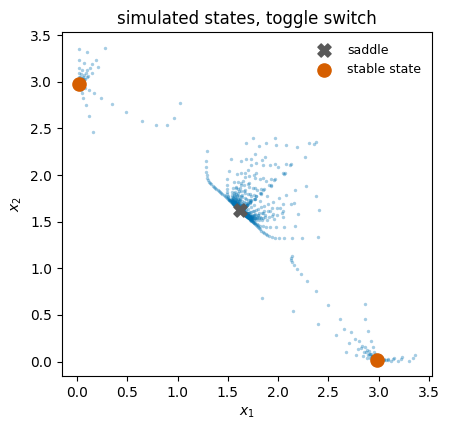

In [4]:
X = np.asarray(adata_t.layers["Ms"])
eq = toggle.equilibria()

fig, ax = plt.subplots(figsize=(4.6, 4.4))
ax.scatter(X[:, 0], X[:, 1], s=6, c="#0072B2", alpha=0.35, linewidths=0)
for i, p in enumerate(eq):
    stable = not np.allclose(p[0], p[1], atol=1e-3)
    ax.scatter(*p, s=90, marker="o" if stable else "X",
               c="#D55E00" if stable else "0.35", zorder=5,
               label=("stable state" if stable else "saddle") if i < 2 else None)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("simulated states, toggle switch")
handles, labels = ax.get_legend_handles_labels()
seen = dict(zip(labels, handles))
ax.legend(seen.values(), seen.keys(), frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 3. Recovering the interaction matrix

`fit_circuit` fits $W$ and $I$ against the simulated velocity under one of three structural
regimes:

| `scaffold_mode` | what the fit is told |
| :-- | :-- |
| `full` | the true set of edges |
| `partial` | the true edges plus a fraction of false positives |
| `none` | nothing, every edge free |

This is the same restriction the real-data tutorials apply, where the scaffold comes from a base
regulatory network rather than from the truth. Scoring against the known $W$ shows what the
restriction is worth.

In [5]:
rows = []
fits_t = {}
for mode in ["full", "partial", "none"]:
    t0 = time.time()
    res = sch.validation.fit_circuit(adata_t, scaffold_mode=mode, device=DEVICE, seed=0)
    fits_t[mode] = res
    s = sch.validation.summarize_recovery(res["W_inferred"], res["W_true"])
    s = {"scaffold": mode, **s, "seconds": round(time.time() - t0, 1)}
    rows.append(s)
    print(f"  {mode:8s} sign accuracy {s['edge_sign_accuracy']:.3f}  "
          f"signed correlation {s['edge_correlation']:.6f}  ({s['seconds']:.0f} s)")

recovery_toggle = pd.DataFrame(rows).set_index("scaffold")
recovery_toggle

  full     sign accuracy 1.000  signed correlation 1.000000  (83 s)


  partial  sign accuracy 1.000  signed correlation 1.000000  (162 s)


  none     sign accuracy 1.000  signed correlation 1.000000  (60 s)


,edge_sign_accuracy,edge_correlation,spectral_overlap,frobenius_distance,symmetry_inferred,symmetry_true,seconds
scaffold,,,,,,,
full,1.0,1.0,0.998353,0.000366,0.000013,0.0,82.7
partial,1.0,1.0,0.997277,0.000727,0.000345,0.0,161.7
none,1.0,1.0,0.998353,0.000366,0.000013,0.0,60.0


In [6]:
print("W recovered with the full scaffold:\n", fits_t["full"]["W_inferred"])
print("\nW true:\n", fits_t["full"]["W_true"])
print("\nW recovered with no scaffold at all:\n", fits_t["none"]["W_inferred"])

W recovered with the full scaffold:
 [[ 5.0011 -3.9983]
 [-3.9981  5.0018]]

W true:
 [[ 5. -4.]
 [-4.  5.]]

W recovered with no scaffold at all:
 [[ 5.0011 -3.9983]
 [-3.9981  5.0018]]


Two genes give four possible edges, so even an unrestricted fit is well determined here: there is
far more data than parameters. That is exactly why this is the wrong place to argue for the
scaffold, and why the argument is made on real data instead, where the gene count is in the
thousands and the cells are not. What this circuit establishes is the other half of the claim,
that the inference machinery recovers the right answer when the right answer is knowable.

## 4. Observation noise

Real measurements are not analytic derivatives. Adding Gaussian noise to the simulated
observations shows which parts of the recovery are robust and which are not.

In [7]:
noise_rows = []
for sigma in [0.0, 0.1, 0.25, 0.5]:
    a = sch.validation.simulate_circuit(
        toggle, n_trajectories=50, points_per_trajectory=40, t_end=6.0,
        noise_sigma=sigma, seed=0)
    res = sch.validation.fit_circuit(a, scaffold_mode="full", device=DEVICE, seed=0)
    s = sch.validation.summarize_recovery(res["W_inferred"], res["W_true"])
    noise_rows.append({"noise_sigma": sigma, **s})
    print(f"  sigma={sigma:<5} sign accuracy {s['edge_sign_accuracy']:.3f}  "
          f"signed correlation {s['edge_correlation']:.4f}")

noise_df = pd.DataFrame(noise_rows).set_index("noise_sigma")
noise_df[["edge_sign_accuracy", "edge_correlation", "frobenius_distance"]]

  sigma=0.0   sign accuracy 1.000  signed correlation 1.0000


  sigma=0.1   sign accuracy 1.000  signed correlation 1.0000


  sigma=0.25  sign accuracy 1.000  signed correlation 1.0000


  sigma=0.5   sign accuracy 1.000  signed correlation 0.9999


,edge_sign_accuracy,edge_correlation,frobenius_distance
noise_sigma,,,
0.00,1.0,1.000000,0.000366
0.10,1.0,0.999992,0.009433
0.25,1.0,0.999978,0.064767
0.50,1.0,0.999933,0.300493


What degrades is not what one might expect. Across this range the edge **signs** are recovered
perfectly and the signed correlation stays at the top of its range: the question of who regulates
whom, and in which direction, is answered correctly throughout. What drifts is the **magnitude**,
and the normalized Frobenius distance is the column that shows it, growing by orders of magnitude
while the other two columns do not move.

That split is the useful lesson. The structural conclusions this method draws are far more robust
to observation noise than the numerical values of the interaction strengths, which is worth
remembering when reading a fitted $W$ on real data.

## 5. The energy landscape, and why symmetry matters

For a symmetric $W$ the system has a Lyapunov function,

$$E(x) = -\tfrac{1}{2}\,\sigma(x)^{\top} W \sigma(x)
        + \sum_i \gamma_i \!\int^{\sigma_i} \!\sigma_i^{-1}
        - I^{\top}\sigma(x),$$

which never increases along a trajectory. Its minima are then exactly the stable states, and
"energy landscape" is a literal statement rather than a metaphor.

`compute_energies` is the same function the real-data tutorials call. Here we hand it a grid of
hypothetical states rather than measured cells, which turns it into a way to draw the landscape
over the whole plane.

In [8]:
g = np.linspace(0.01, 3.5, 120)
G1, G2 = np.meshgrid(g, g)
grid = np.column_stack([G1.ravel(), G2.ravel()])

surface = ad.AnnData(
    X=grid.copy(),
    obs=pd.DataFrame({"cluster": "synthetic"},
                     index=[f"s{i}" for i in range(grid.shape[0])]),
    var=pd.DataFrame(index=list(toggle.gene_names)),
)
surface.layers["Ms"] = grid.copy()
surface.var["scHopfield_used"] = True
surface.var["gamma"] = toggle.gamma_vec()
surface.var["sigmoid_threshold"] = float(toggle.k)
surface.var["sigmoid_exponent"] = float(toggle.n)
surface.var["I_synthetic"] = toggle.I_vec()
surface.varp["W_synthetic"] = toggle.W()

sch.pp.compute_sigmoid(surface, spliced_key="Ms")
sch.tl.compute_energies(surface, cluster_key="cluster")
E = surface.obs["energy_total"].values.reshape(G1.shape)

for p in eq:
    i = int(np.argmin((grid[:, 0] - p[0]) ** 2 + (grid[:, 1] - p[1]) ** 2))
    kind = "saddle" if np.allclose(p[0], p[1], atol=1e-3) else "stable"
    print(f"  E at the {kind:6s} equilibrium {np.round(p, 3)}: "
          f"{surface.obs['energy_total'].values[i]:.4f}")
print(f"  lowest energy anywhere on the grid: {E.min():.4f}")

  E at the saddle equilibrium [1.625 1.625]: -2.7599
  E at the stable equilibrium [2.979 0.017]: -3.2051
  E at the stable equilibrium [0.017 2.979]: -3.2051
  lowest energy anywhere on the grid: -3.2051


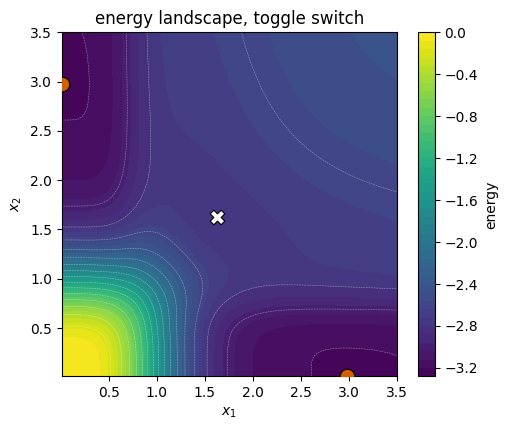

In [9]:
fig, ax = plt.subplots(figsize=(5.2, 4.4))
cf = ax.contourf(G1, G2, E, levels=40, cmap="viridis")
ax.contour(G1, G2, E, levels=20, colors="white", linewidths=0.35, alpha=0.5)
for p in eq:
    stable = not np.allclose(p[0], p[1], atol=1e-3)
    ax.scatter(*p, s=110, marker="o" if stable else "X",
               facecolor="#D55E00" if stable else "white",
               edgecolor="black", linewidth=0.8, zorder=5)
fig.colorbar(cf, ax=ax, label="energy")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("energy landscape, toggle switch")
fig.tight_layout()
plt.show()

The two basins are the two stable states, and the saddle sits on the ridge between them, at a
higher energy than either. A cell in one basin does not cross to the other without something
pushing it, which is what makes the switch a commitment rather than a preference.

The Lyapunov property is worth checking rather than taking on faith. Along any trajectory the
energy should only ever fall.

  start [0.5 0.4]: largest energy increase along the path 4.44e-16
  start [0.4 0.5]: largest energy increase along the path 1.33e-15
  start [3. 2.]: largest energy increase along the path -1.65e-07


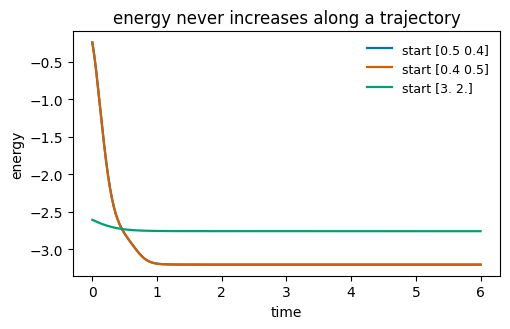

In [10]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
for x0, color in [(np.array([0.5, 0.4]), "#0072B2"),
                  (np.array([0.4, 0.5]), "#D55E00"),
                  (np.array([3.0, 2.0]), "#009E73")]:
    ts, traj = toggle.simulate(t_end=6.0, n_samples=200, initial_state=x0)
    probe = ad.AnnData(
        X=traj.copy(),
        obs=pd.DataFrame({"cluster": "synthetic"},
                         index=[f"t{i}" for i in range(traj.shape[0])]),
        var=pd.DataFrame(index=list(toggle.gene_names)),
    )
    probe.layers["Ms"] = traj.copy()
    probe.var["scHopfield_used"] = True
    probe.var["gamma"] = toggle.gamma_vec()
    probe.var["sigmoid_threshold"] = float(toggle.k)
    probe.var["sigmoid_exponent"] = float(toggle.n)
    probe.var["I_synthetic"] = toggle.I_vec()
    probe.varp["W_synthetic"] = toggle.W()
    sch.pp.compute_sigmoid(probe, spliced_key="Ms")
    sch.tl.compute_energies(probe, cluster_key="cluster")
    e = probe.obs["energy_total"].values
    ax.plot(ts, e, color=color, lw=1.6, label=f"start {np.round(x0, 2)}")
    rise = np.max(np.diff(e))
    print(f"  start {np.round(x0, 2)}: largest energy increase along the path {rise:.2e}")

ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.set_title("energy never increases along a trajectory")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 6. The repressilator

Three genes in a cycle, each repressing the next. Written in the scHopfield form its $W$ is a
cyclic matrix of negative entries, and crucially it is **not symmetric**: gene $x$ represses $y$,
but $y$ does not repress $x$.

In [11]:
osc = OscillatorCircuit()      # alpha=10, k=1, n=4, gamma=1
print(osc)
print("\nW (true):\n", osc.W())
print("W is symmetric:", np.allclose(osc.W(), osc.W().T))
print("has a limit cycle:", osc.has_limit_cycle())

OscillatorCircuit(alpha=10.0, k=1.0, n=4, gamma=1.0)

W (true):
 [[ -0.  -0. -10.]
 [-10.  -0.  -0.]
 [ -0. -10.  -0.]]
W is symmetric: False
has a limit cycle: True


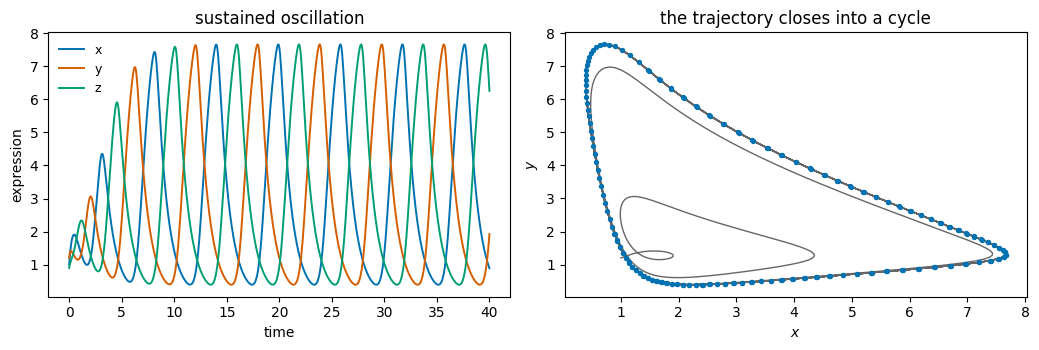

In [12]:
ts, traj = osc.simulate(t_end=40.0, n_samples=800,
                        initial_state=np.array([1.0, 1.2, 0.9]))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
for i, (name, color) in enumerate(zip(osc.gene_names, ["#0072B2", "#D55E00", "#009E73"])):
    axes[0].plot(ts, traj[:, i], color=color, lw=1.4, label=name)
axes[0].set_xlabel("time")
axes[0].set_ylabel("expression")
axes[0].set_title("sustained oscillation")
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(traj[:, 0], traj[:, 1], color="0.4", lw=1.0)
axes[1].scatter(traj[-200:, 0], traj[-200:, 1], s=8, c="#0072B2", zorder=3)
axes[1].set_xlabel(f"${osc.gene_names[0]}$")
axes[1].set_ylabel(f"${osc.gene_names[1]}$")
axes[1].set_title("the trajectory closes into a cycle")
fig.tight_layout()
plt.show()

In [13]:
adata_o = sch.validation.simulate_circuit(
    osc, n_trajectories=50, points_per_trajectory=40, t_end=6.0, seed=0)

rows = []
for mode in ["full", "partial", "none"]:
    res = sch.validation.fit_circuit(adata_o, scaffold_mode=mode, device=DEVICE, seed=0)
    s = sch.validation.summarize_recovery(res["W_inferred"], res["W_true"])
    rows.append({"scaffold": mode, **s})
    print(f"  {mode:8s} sign accuracy {s['edge_sign_accuracy']:.3f}  "
          f"signed correlation {s['edge_correlation']:.6f}")

recovery_osc = pd.DataFrame(rows).set_index("scaffold")
# symmetry_index is ||W - W^T|| / ||W + W^T||: zero for a symmetric matrix, large when the
# antisymmetric part dominates. The toggle scores ~0; the repressilator does not.
recovery_osc[["edge_sign_accuracy", "edge_correlation", "frobenius_distance",
              "symmetry_inferred", "symmetry_true"]]

  full     sign accuracy 1.000  signed correlation 1.000000


  partial  sign accuracy 1.000  signed correlation 0.999998


  none     sign accuracy 1.000  signed correlation 1.000000


,edge_sign_accuracy,edge_correlation,frobenius_distance,symmetry_inferred,symmetry_true
scaffold,,,,,
full,1.0,1.000000,0.000336,0.999578,1.0
partial,1.0,0.999998,0.002666,1.001936,1.0
none,1.0,1.000000,0.003650,1.004183,1.0


## 7. Why the energy is not the whole story here

With an asymmetric $W$ the energy is no longer guaranteed to decrease, and for this circuit it
does not: the system runs a cycle forever, so nothing about it is monotone. The energy is still
computable and still informative about where the system is reluctant to go, but it is a
quasi-potential rather than a Lyapunov function, and it has to be read alongside the Jacobian.

The Jacobian is what carries the oscillation. At the circuit's single fixed point its
eigenvalues include a complex-conjugate pair, which is a rotation, and that pair has a
**positive** real part, which means the rotation grows rather than decays. The system is pushed
away from its own fixed point and out onto the cycle.

In [14]:
# The fixed point is symmetric in the three genes, so it solves a scalar equation.
f = lambda p: -osc.alpha * osc.sigma(np.array([p, p, p]))[0] - p + osc.alpha
p_star = brentq(f, 1e-6, 100.0)
x_star = np.array([p_star, p_star, p_star])
J = osc.jacobian(x_star)
eigs = np.linalg.eigvals(J)

print(f"fixed point: x* = {np.round(x_star, 4)}")
print("Jacobian:\n", J)
print("\neigenvalues:", np.round(eigs, 4))
complex_pair = eigs[np.abs(eigs.imag) > 1e-9]
print(f"\ncomplex-conjugate pair: {np.round(complex_pair, 4)}")
print(f"real part of that pair: {complex_pair.real[0]:+.4f}  "
      f"({'unstable, the system spirals outward' if complex_pair.real[0] > 0 else 'stable'})")

fixed point: x* = [1.533 1.533 1.533]
Jacobian:
 [[-1.     -0.     -3.3868]
 [-3.3868 -1.     -0.    ]
 [-0.     -3.3868 -1.    ]]

eigenvalues: [-4.3868+0.j      0.6934+2.9331j  0.6934-2.9331j]

complex-conjugate pair: [0.6934+2.9331j 0.6934-2.9331j]
real part of that pair: +0.6934  (unstable, the system spirals outward)


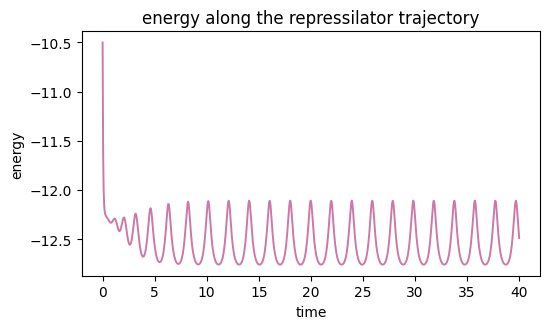

largest energy increase along the path: 0.0753
the energy rises as well as falls, so it is not a Lyapunov function here


In [15]:
probe = ad.AnnData(
    X=traj.copy(),
    obs=pd.DataFrame({"cluster": "synthetic"},
                     index=[f"t{i}" for i in range(traj.shape[0])]),
    var=pd.DataFrame(index=list(osc.gene_names)),
)
probe.layers["Ms"] = traj.copy()
probe.var["scHopfield_used"] = True
probe.var["gamma"] = osc.gamma_vec()
probe.var["sigmoid_threshold"] = float(osc.k)
probe.var["sigmoid_exponent"] = float(osc.n)
probe.var["I_synthetic"] = osc.I_vec()
probe.varp["W_synthetic"] = osc.W()
sch.pp.compute_sigmoid(probe, spliced_key="Ms")
sch.tl.compute_energies(probe, cluster_key="cluster")
e_osc = probe.obs["energy_total"].values

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(ts, e_osc, color="#CC79A7", lw=1.4)
ax.set_xlabel("time")
ax.set_ylabel("energy")
ax.set_title("energy along the repressilator trajectory")
fig.tight_layout()
plt.show()

print(f"largest energy increase along the path: {np.max(np.diff(e_osc)):.4f}")
print("the energy rises as well as falls, so it is not a Lyapunov function here")

## 8. What a linear model cannot do

The saturating activation is not decoration. Replace $\sigma(x)$ with $x$ and the model becomes
$\dot{x} = Ax + b$, whose fixed points solve $Ax = -b$. For any invertible $A$ that has exactly
one solution, so a linear autonomous model has **at most one steady state** and cannot represent a
switch at all, no matter how well it is fit or how much data it is given.

The comparison below is made against the circuit's analytic vector field, evaluated on the same
grid the energy was drawn on rather than on the sampled trajectories. That keeps it a fair test of
the two function classes: both see exactly the same field, and neither is helped or hurt by where
the sampling happened to land.

In [16]:
V_true = np.array([toggle.rhs(p) for p in grid])

design = np.hstack([grid, np.ones((grid.shape[0], 1))])
coef, *_ = np.linalg.lstsq(design, V_true, rcond=None)
A, b = coef[:2].T, coef[2]

v_pred = design @ coef
r2 = 1 - ((V_true - v_pred) ** 2).sum() / ((V_true - V_true.mean(0)) ** 2).sum()
print(f"linear fit R^2 on the true velocity field: {r2:.3f}")
print(f"condition number of A: {np.linalg.cond(A):.1f}   (its fixed point is well determined)")

fixed = np.linalg.solve(A, -b)
print(f"\nthe linear model only admits one fixed point: {np.round(fixed, 4)}")
print("the circuit has three equilibria:")
for p in eq:
    kind = "saddle" if np.allclose(p[0], p[1], atol=1e-3) else "stable"
    print(f"   {np.round(p, 4)}  ({kind})")

linear fit R^2 on the true velocity field: 0.772
condition number of A: 92.1   (its fixed point is well determined)

the linear model only admits one fixed point: [1.5379 1.5379]
the circuit has three equilibria:
   [1.6248 1.6248]  (saddle)
   [2.9791 0.0167]  (stable)
   [0.0167 2.9791]  (stable)


The linear model accounts for a respectable share of the velocity field. It is not a strawman: as a
description of the motion it is reasonable. It is still structurally incapable of what the circuit
does. It admits exactly one fixed point, that point sits near the **saddle**, and the
saddle is the one equilibrium the real system never rests in. The two states the circuit actually
occupies are invisible to it.

That is the point of the whole construction. A model can reproduce the motion and still be
incapable of representing the structure that motion implies. Restricting the nonlinearity to a
saturating activation per gene keeps the model identifiable while leaving multistability and
oscillation available to it.

## Where to go next

- **Getting started** fits the same machinery to pancreatic endocrinogenesis.
- **Reading the fitted system** takes the energy and Jacobian views of this tutorial to real
  data, where the equilibria are not known in advance.